# import

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution_TurbulenceNoise import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [4]:
# Integrate numerically the angular dynamics of each strategy
# Calculate the scalar product between t at the end of the evolution
# and the real source position

    
def EvolutionTurbulenceNoise(Grad, Intensity):

    # Function to evaluate the scalar product between t at the end of the evolution
    # and the real source position
    #input:
    # Gradient (source flow measured)
    #output:
    # dot product as a 2D map
    # variance of dot product as 2D map
    
    # Noise intensity
    
    # t axis for Triangulation strategy absence of roll
    t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))

    # Resulting dot products
    DotProduct_T = np.zeros((NPoints, NPoints, NTrials))

    for k in range(NPoints):
        for i in range(NPoints):
            AgentPosition =  np.array([z[k], x[i], 0.])
            OptimalDirection = -np.copy(AgentPosition/np.linalg.norm(AgentPosition))

            for trials_i in range(NTrials):
                # Random orientation of agent axis
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

                n_T = np.dot(RotationMatrix,[0, 1, 0])
                b_T = np.dot(RotationMatrix,[0, 0, 1])
                t_T = np.dot(RotationMatrix,[1, 0, 0])


                # Time integration of strategies
                for time in range(Duration):
                    n_T, b_T, t_T = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, AgentPosition, Grad, e3, dt, roll, Intensity)
                
                t0_T[k, i, trials_i], t1_T[k, i, trials_i], t2_T[k, i, trials_i] = t_T
                DotProduct_T[k, i, trials_i] = np.dot(t_T, OptimalDirection)

    return DotProduct_T,\
        t0_T, t1_T#,\
        #t0_T_not, t1_T_not,\
        #t0_I, t1_I # DotProduct_T_not, DotProduct_I,\


In [5]:
# Data
NPoints = 80 # Grid number of points per axis
NTrials = 30 # Number of trial x point

Duration = 255
AntennaeLength = .01 # Sensors distance, on antennae
x = np.linspace(0.1, 5, NPoints) # x axis
z = np.linspace(0.1, 5, NPoints) # z axis
X, Z = np.meshgrid(x, z)
e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
roll = .4 # Roll Intensity
NameStrategies = ["T"] #_not", "T", "I"] 

In [11]:
# 

# Information flow 
GradName = ['GradientStresslet', 'StrainStresslet', 'GradientStokeslet', 'StrainStokeslet'] # 'ShearQuadruplet', 'GradientQuadruplet', 
Grads =  [GradientStresslet, StrainStresslet, GradientStokeslet, StrainStokeslet] #  GradientStresslet, ShearStokeslet, GradientStokeslet] # ShearQuadruplet, GradientQuadruplet


for grads_i, Grad in enumerate(Grads):
    Intensity = 0.1*np.linalg.norm(Grad(e3, np.array([2,0,0])))

    t0_T, t1_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    
    # Evaluate the strategy 2D map, vector P 
    Avg_P_T = np.zeros((NPoints, NPoints, NTrials))
    
    # Call Evaluation function and evaluate 
    Avg_P_T, t0_T, t1_T = EvolutionTurbulenceNoise(Grad, Intensity)
    
    # Save data

    AllAvg = [Avg_P_T] #_not, Avg_P_T, Avg_P_I]
    Allt0 = [t0_T] #_not, t0_T, t0_I]
    Allt1 = [t1_T] #_not, t1_T, t1_I]

    for i, strat_name in enumerate(NameStrategies):
        np.savetxt("Data_TurbulenceNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".txt", np.mean(AllAvg[i], axis = 2), delimiter = ',')
        np.savetxt("Data_TurbulenceNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".txt", np.mean(Allt0[i], axis = 2), delimiter = ',')
        np.savetxt("Data_TurbulenceNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".txt", np.mean(Allt1[i], axis = 2), delimiter = ',')
                  


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


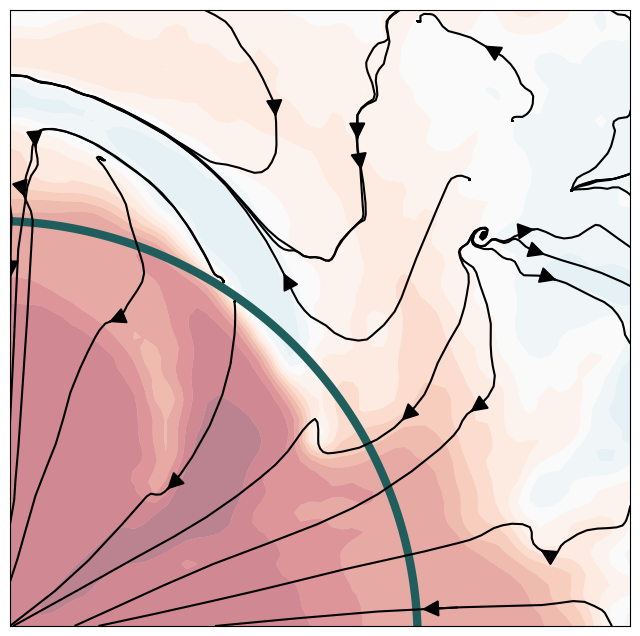

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


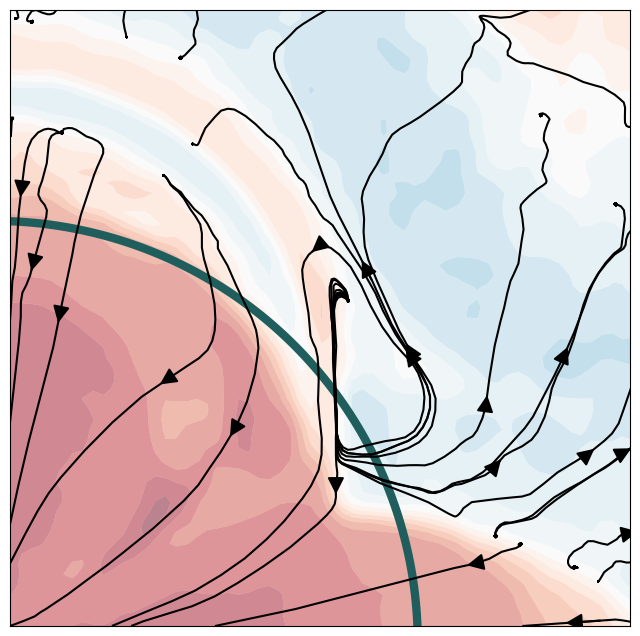

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


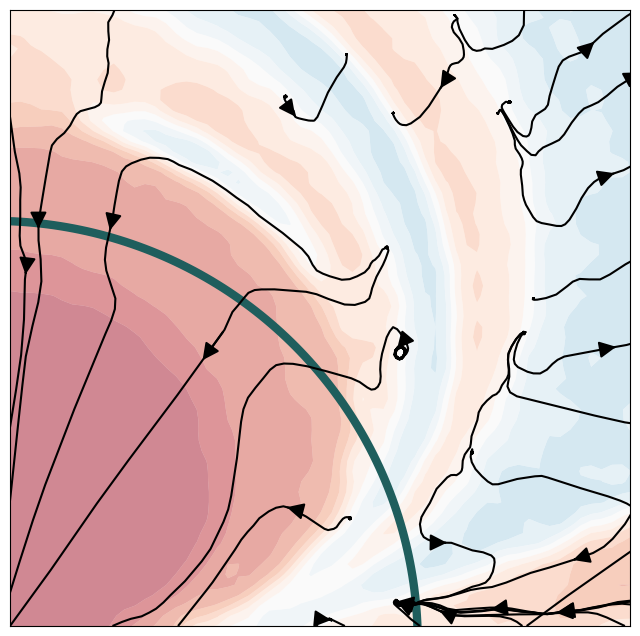

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


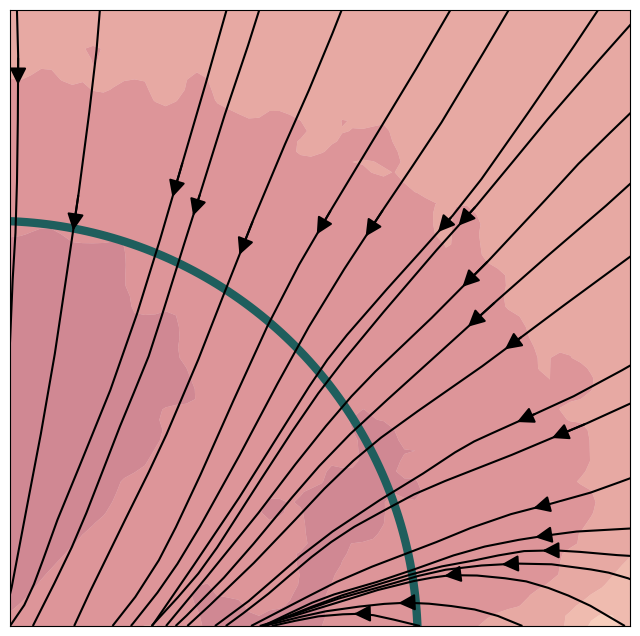

In [9]:
# Plot data from Save 
# Information flow 
GradName = ['GradientStresslet',  'StrainStresslet', 'StrainStokeslet', 'GradientStokeslet'] # 'ShearQuadruplet', 'GradientQuadruplet', 
Grads =  [GradientStresslet, StrainStresslet, StrainStokeslet, GradientStokeslet] # ShearQuadruplet, GradientQuadruplet

import scipy.ndimage as ndimage # import to smooth plots
from scipy.special import erf
Trial = 10
for grads_i, Grad in enumerate(GradName):
    Intensity = 0.1*np.linalg.norm(Grads[grads_i](e3, np.array([2,0,0]))) # This is noise intensity
    for i, strat_name in enumerate(NameStrategies):
        # Compute GradField Intensity over X, Z
        GradField = np.zeros_like(X)
        gradient_values = np.zeros(Trial)
        for ix in range(X.shape[0]):
            for iz in range(X.shape[1]):
                for t in range(Trial):
                    theta = 2 * np.pi * t / Trial  # Angle for this trial
                    n_reference = np.array([np.cos(theta), np.sin(theta), 0.0])  # Unit vector on a circle
                    position = np.array([Z[ix, iz], X[ix, iz], 0.0]) 
                    gradient_values = np.linalg.norm(np.dot(n_reference, Grads[grads_i](e3, position)))
                GradField[ix, iz] = np.mean(gradient_values)
        # Extract data from saved file
        with open("Data_TurbulenceNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".txt", 'r') as the_file:
            Avg = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 


        with open("Data_TurbulenceNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".txt", 'r') as the_file:

            t0 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 
        with open("Data_TurbulenceNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".txt", 'r') as the_file:

            t1 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 

        # Plot parameters
        # Add 1/4 circle arc at radius r = (6/Intensity)**(1/3)
        r_arc = (1.0 / Intensity)**(1/3)
        theta_arc = np.linspace(0, np.pi/2, 100)  # 0 to 90 degrees
        x_arc = r_arc * np.cos(theta_arc)
        z_arc = r_arc * np.sin(theta_arc)
        CMAP = 'RdBu_r' #'spring'
        STREAMCOLOR = 'black'
        
        MAX_VALUE = 1
        MIN_VALUE = -1
        
        fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
        ax1 = axs
        X, Z = np.meshgrid(x, z, indexing='xy')
        
        ax1.plot(x_arc, z_arc, color='#1F5E5D', linestyle='-', linewidth=6)
        # Add data to image grid
        levels = np.linspace(-1, 1.00001, 20)

        Avg = ndimage.gaussian_filter(Avg, sigma=1.0, order=0)
        im = ax1.contourf(X, Z, Avg, cmap = CMAP, levels = levels, vmin= MIN_VALUE, vmax = MAX_VALUE, alpha = 0.5, antialiased=True)
        ax1.streamplot(X, Z, t1, t0, color = STREAMCOLOR,  density = .3,  arrowsize = 2.5, broken_streamlines=False)
        #contour_line = ax1.contour(X, Z, GradField, levels=[SENSORY_PERIMETER], colors='green', linewidths=3)
        #ax1.clabel(contour_line, fmt={SENSORY_PERIMETER: f'{SENSORY_PERIMETER:.2f}'}, inline=True, fontsize=10)

        #PlotCircles(ax1, .5)
        ax1.set_xlim([.1, 1.5*r_arc])
        ax1.set_ylim([.1, 1.5*r_arc])
        ax1.set_xticks([])
        ax1.set_yticks([])



        #plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
        # Uncomment to save
        plt.savefig("Plots_TurbulenceNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".eps", format = 'eps', bbox_inches='tight')
        plt.savefig("Plots_TurbulenceNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+"_Intensiy_"+str(np.round(Intensity, 3))+".pdf", bbox_inches='tight')
        plt.show()

0.06123724356957945